In [3]:
# Импорт необходимых библиотек
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# загружаем датасет (уже очищен от нуллов и выбросов)
df = pd.read_csv('data/merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


In [3]:
# Рассчитываем по каждому городу:
# Среднюю выручку на 1 пользователя за месяц (sum_total)
# Считаем количество тренировок для каждого пользователя (cnt_total)
pay_user = df.groupby(['id_user', 'city']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                               'sum_total':'sum'})\
    .reset_index().rename(columns = {'mon':'nmonths'})
# Добавляем новый столбец со средней выручкой в месяц (avg_monthly_revenue)
pay_user['avg_monthly_revenue'] = pay_user['sum_total']/pay_user['nmonths']
# И столбец с долей индивидуальных тренировок (share_indiv)
pay_user['share_indiv'] = pay_user['cnt_indiv']/pay_user['cnt_total']
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total,avg_monthly_revenue,share_indiv
0,1000,СПб,9,33,33,58600,6511.111111,1.000000
1,1001,Москва,11,23,129,124800,11345.454545,0.178295
2,1002,Москва,11,64,128,166000,15090.909091,0.500000
3,1004,Екатеринбург,9,18,18,32000,3555.555556,1.000000
4,1005,СПб,2,7,7,12600,6300.000000,1.000000


In [4]:
# Группируем по городам: количество уникальных пользователей (nusers),
                       # среднее значение выручки по месяцам (avg_monthly_revenue)
                       # среднее значение доли индивидуальных тренировок (share_indiv)
city_stats = pay_user.groupby('city').agg({'id_user':'nunique',
                                          'avg_monthly_revenue':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
city_stats

,city,nusers,avg_monthly_revenue,share_indiv
0,Екатеринбург,128,6735.819862,0.308108
1,Казань,127,6698.701412,0.247886
2,Москва,310,7194.958013,0.654638
3,СПб,273,7123.468912,0.333030


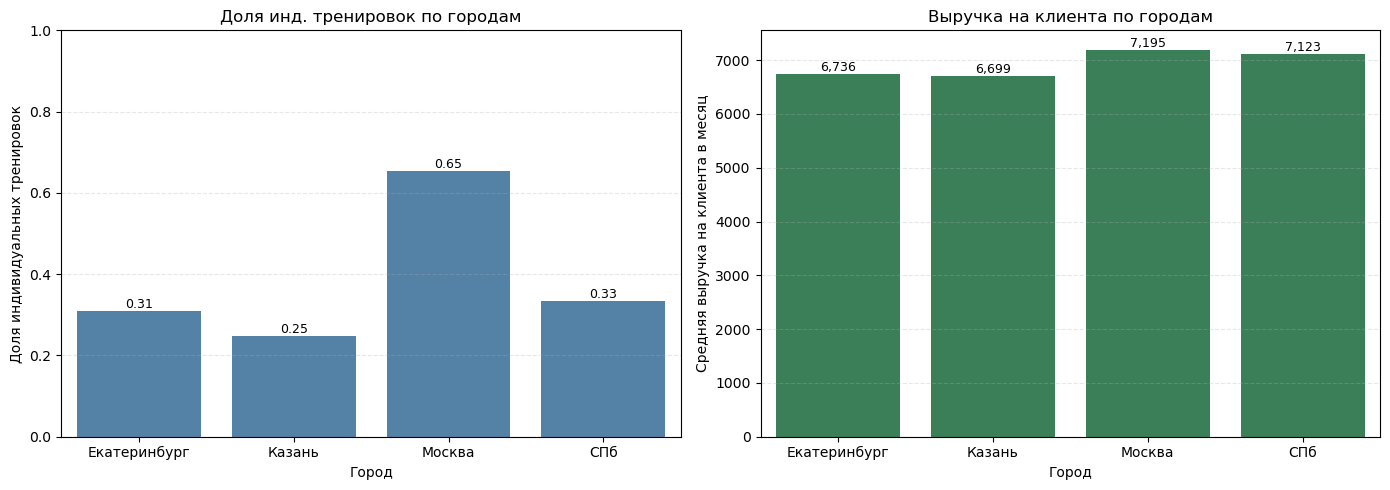

In [15]:
# Создаём график с двумя подграфиками для наглядности и сравнения результатов 
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Доля индивидуальных тренировок по городам 
sns.barplot(
    data=city_stats,
    x='city',
    y='share_indiv',
    color='steelblue',          
    ax=axs[0])
axs[0].set_ylim(0, 1)           
axs[0].set_xlabel('Город')
axs[0].set_ylabel('Доля индивидуальных тренировок')
axs[0].set_title('Доля инд. тренировок по городам')
axs[0].grid(axis='y', linestyle='--', alpha=0.3)  

# Добавим значения прямо на столбцы
for p in axs[0].patches:
    height = p.get_height()
    axs[0].annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', fontsize=9)

# График 2: Средняя выручка на 1 клиента в месяц 
sns.barplot(
    data=city_stats,
    x='city',
    y='avg_monthly_revenue',
    color='seagreen',           
    ax=axs[1])
axs[1].set_ylim(bottom=0)
axs[1].set_xlabel('Город')
axs[1].set_ylabel('Средняя выручка на клиента в месяц')
axs[1].set_title('Выручка на клиента по городам')
axs[1].grid(axis='y', linestyle='--', alpha=0.3)

for p in axs[1].patches:
    height = p.get_height()
    axs[1].annotate(
        f'{height:,.0f}',        # формат с разделителем тысяч (например, 3 500)
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Изучаем ключевые метрики по возрастным группам
# 1.Разделим клиентов на три возрастные группы:
# - до 30 лет
# - от 30 до 45 лет
# - старше 45 лет
def age_group(age):
    if pd.isna(age):
        return None
    if age <= 30:
        return '18-30'
    elif 31 <= age <= 45:
        return '31-45'
    else:
        return '46+'

df['age_gr'] = df['age'].apply(age_group)
age_user = df.groupby(['id_user', 'age_gr']).agg({'mon':'count',
                                               'cnt_indiv':'sum',
                                               'cnt_total':'sum',
                                               'sum_total':'sum'})\
    .reset_index().rename(columns = {'mon':'nmonths'})
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,31-45,9,33,33,58600
1,1001,31-45,11,23,129,124800
2,1002,31-45,11,64,128,166000
3,1004,46+,9,18,18,32000
4,1005,31-45,2,7,7,12600


In [20]:
# Для каждой возрастной группы рассчитаем метрики и добавим в соответствующие столбцы:
# - Среднюю долю индивидуальных тренировок
age_user['share_indiv'] = age_user['cnt_indiv']/age_user['cnt_total']
# - Среднее количество тренировок в месяц
age_user['avg_train_per_mon'] = age_user['cnt_total']/age_user['nmonths']
# - Среднюю выручку на 1 пользователя за месяц
age_user['avg_monthly_revenue'] = age_user['sum_total']/age_user['nmonths']
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total,share_indiv,avg_train_per_mon,avg_monthly_revenue
0,1000,31-45,9,33,33,58600,1.000000,3.666667,6511.111111
1,1001,31-45,11,23,129,124800,0.178295,11.727273,11345.454545
2,1002,31-45,11,64,128,166000,0.500000,11.636364,15090.909091
3,1004,46+,9,18,18,32000,1.000000,2.000000,3555.555556
4,1005,31-45,2,7,7,12600,1.000000,3.500000,6300.000000


In [21]:
# Деление на сегменты по ключевым метрикам
age_segm = age_user.groupby('age_gr').agg({'id_user':'nunique',
                                          'nmonths':'mean',
                                          'avg_monthly_revenue':'mean',
                                          'avg_train_per_mon':'mean',
                                          'share_indiv':'mean'}).\
    reset_index().rename(columns = {'id_user': 'nusers'})

age_segm

,age_gr,nusers,nmonths,avg_monthly_revenue,avg_train_per_mon,share_indiv
0,18-30,278,5.399281,8222.747802,7.290366,0.446690
1,31-45,271,5.343173,7774.985357,7.003930,0.445543
2,46+,289,5.681661,5173.422485,4.737098,0.414714


**Выручка:** 18–30 → 8222 ₽; 31–45 → 7775 ₽; 46+ → 5173 ₽.  
**Индивидуальные тренировки:** 7.3 / 7.0 / 4.7 в месяц.  
**Доля индивидуальных тренировок:** 41–45% по всем группам.  
**Удержание:** 5.3–5.7 месяца — без значимых различий по возрасту.  
**Следствие:** группа 46+ даёт заметно меньшую выручку при схожем удержании и интересе к формату.

In [24]:
# Изучаем премиальный сегмент
# Найдем 10 пользователей с самой высокой совокупной выручкой.
df_gr = df.groupby('id_user').agg({'sum_total':'sum'})\
    .reset_index().sort_values('sum_total', ascending = False).head(10)
# Сохраним их id в список и выведем для них отдельную таблицу
user_lst = df_gr['id_user'].tolist()
user_lst

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [25]:
df_top = df[df['id_user'].isin(user_lst)]
# Выведем для этих пользователей город, пол, среднюю выручку за месяц, 
# среднее количество тренировок в месяц и количество месяцев, которые они 
# тренировались.
user_top = df_top.groupby(['id_user', 'city', 'gender', 'age_gr']).agg({'mon':'count',
                                                                       'cnt_total':'sum',
                                                                       'sum_total':'sum'})\
    .reset_index().rename(columns = {'mon':'nmonths'})
user_top['avg_monthly_revenue'] = user_top['sum_total']/user_top['nmonths']
user_top['avg_train_per_mon'] = user_top['cnt_total']/user_top['nmonths']
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total,avg_monthly_revenue,avg_train_per_mon
0,1002,Москва,male,31-45,11,128,166000,15090.909091,11.636364
1,1013,Москва,male,31-45,11,151,139800,12709.090909,13.727273
2,1029,СПб,female,31-45,8,126,140000,17500.000000,15.750000
3,1153,СПб,male,46+,12,118,147400,12283.333333,9.833333
4,1381,Москва,female,18-30,12,159,147600,12300.000000,13.250000
5,1482,Москва,female,18-30,11,110,131400,11945.454545,10.000000
6,1506,Москва,female,18-30,10,138,146400,14640.000000,13.800000
7,1536,Москва,female,18-30,9,125,134400,14933.333333,13.888889
8,1582,Екатеринбург,male,31-45,8,127,136200,17025.000000,15.875000
9,1657,СПб,male,18-30,10,144,164200,16420.000000,14.400000


**Топ‑10:** средняя выручка по месяцам 12 300–17 500 ₽, лидеры — СПб и Екатеринбург.  
**Активность:** 9.8–15.9 тренировок/мес; у лидеров ~15–16.  
**География:** Москва — 6, СПб — 3, Екатеринбург — 1.  
**Возраст:** 18–30 и 31–45 — основные группы; 46+ — 1 клиент.  
**Срок:** 8–12 месяцев; высокая выручка возможна и на 8–9 месяце.  
**Вывод:** выручка в первую очередь определяется активностью и локацией, а не возрастом или максимальным сроком.

In [20]:
# Изучаем удержание пользователей после первого месяца тренировок:
# приведем даты в таблице к нужному формату
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")
# 1.Создим когорту для каждого пользователя — определим месяц их первого визита 
# (min_mon).
df['cohort_index'] = (df['mon'].dt.year - df['min_mon'].dt.year) * 12 + \
                     (df['mon'].dt.month - df['min_mon'].dt.month) 
# 2.Рассчитаем индекс когорты (cohort_index), который показывает, какой по счёту 
# месяц после первого визита рассматривается для каждого пользователя.
cohort_stats = df.groupby(['min_mon','cohort_index']).agg(active_users = \
                                        ('id_user', 'nunique')).reset_index()
# 3.Для каждой когорты и каждого месяца жизни посчитаем количество уникальных 
# активных пользователей.
cohort_size = cohort_stats[cohort_stats['cohort_index']==0][['min_mon', 'active_users']]\
    .rename(columns = {'active_users':'cohsize'})
cohort_data = cohort_stats.merge(cohort_size, on = 'min_mon')
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [28]:
# 4.Построим когортную таблицу удержания — какая доля пользователей 
# осталась активной в каждом следующем месяце после первого визита.
cohort_data['retention'] = cohort_data['active_users']/cohort_data['cohsize']
# Для удобства воприятия поменяем местами столбцы и строки
retention_table = pd.pivot_table(cohort_data, index = 'min_mon', columns = 'cohort_index',\
                                 values = 'retention')
# Рассмотрим только 4 месяца после первого посещения
retention_table.index = retention_table.index.strftime('%Y-%m')
retention_table.iloc[:, :4]

cohort_index,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


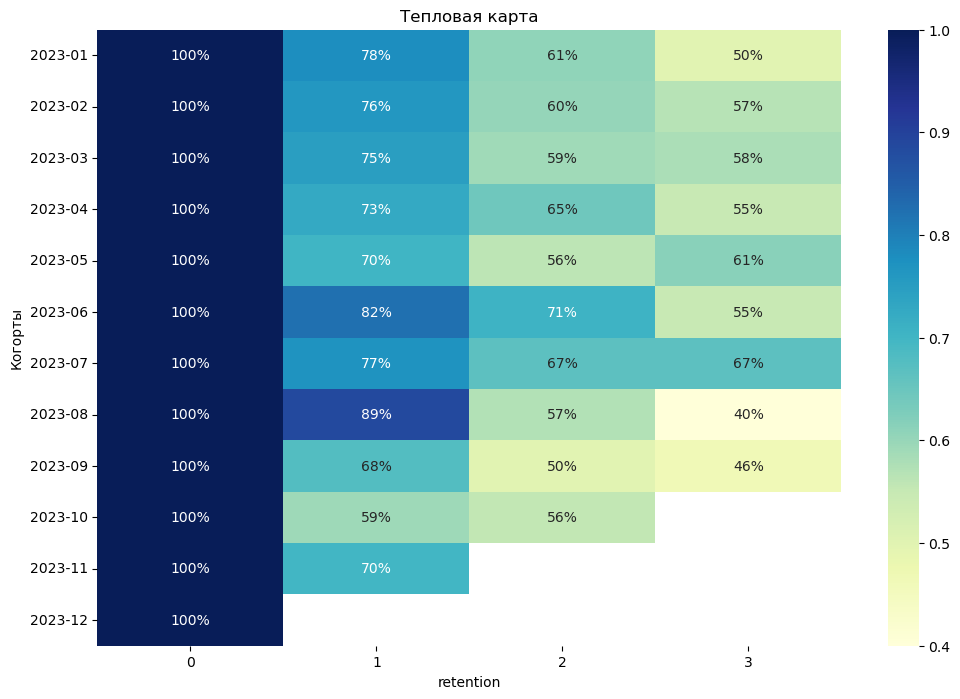

In [29]:
# 5.Визуализируем результаты в виде тепловой карты.
plt.figure(figsize=(12, 8))
sns.heatmap(retention_table.iloc[:, :4], annot = True, fmt = ".0%", cmap = 'YlGnBu')
plt.xlabel('retention')
plt.ylabel('Когорты')
plt.title('Удержание клиентов')
plt.show()

In [7]:
# Рассмотрим подробнее пользователей, которые делают упор на индивидуальные тренировки.
# Определим, что это те пользователи, у которых >70% тренировок — индивидуальные. Сразу 
# добавим столбцы со средним чеком (avg_sum) и средним количеством тренировок в месяц 
# (avg_cnt). Сгруппируем их по городам  и полу.
df['share_indiv'] = df['cnt_indiv']/df['cnt_total']
df_70 = df[df['share_indiv'] > 0.7]
df_70 = df_70.groupby(['id_user', 'city', 'gender']).agg({'sum_total':'mean','cnt_total':'mean'})\
    .round(2).rename(columns = {'sum_total': 'avg_sum', 'cnt_total': 'avg_cnt'})\
    .sort_values('avg_cnt', ascending = False).reset_index()
df_70.head()

,id_user,city,gender,avg_sum,avg_cnt
0,1657,СПб,male,32000.0,20.0
1,1029,СПб,female,21600.0,15.0
2,1482,Москва,female,20800.0,13.0
3,1536,Москва,female,20800.0,13.0
4,1002,Москва,male,17600.0,12.0


**Вывод:**  
* Чаще индивидуальные тренировки выбирают клиенты из Москвы и СПб — у них самые высокие значения avg_cnt (до 20).  
* Зависимость от пола не прослеживается: и мужчины, и женщины встречаются в топе по активности и чеку.  
* Средний чек у активных пользователей высокий — от 14 400 до 32 000 ₽, лидеры по выручке заметно опережают остальных.

In [15]:
# Теперь среди тех, кто предпочитает индивидуальные тренировки найдем топ-10 самых
# активных клиентов. Посчитаем для них общее количество тренировок и общую выручку.
df_aktive = df.groupby(['id_user', 'city', 'gender']).agg(cnt_aktiv = ('cnt_total', 'sum'))\
.sort_values('cnt_aktiv', ascending=False).reset_index()
df_aktive.head(10) # Топ-10 пользователей по количеству тренировок (cnt_total)

,id_user,city,gender,cnt_aktiv
0,1381,Москва,female,159
1,1013,Москва,male,151
2,1657,СПб,male,144
3,1506,Москва,female,138
4,1929,Москва,male,130
5,1001,Москва,female,129
6,1570,Екатеринбург,male,129
7,1002,Москва,male,128
8,1582,Екатеринбург,male,127
9,1194,СПб,female,127


In [17]:
cross_dist = pd.crosstab(df_aktive['city'], df_aktive['gender'], rownames=['Город'], colnames=['Пол'])
cross_dist

Пол,female,male
Город,,
Екатеринбург,52,76
Казань,52,75
Москва,209,101
СПб,122,151


**Вывод:**  
* Среди пользователей, предпочитающих индивидуальные тренировки Москве доля женщин заметно выше мужчин (209 против 101), в остальных городах — примерно равное соотношение или небольшой перевес мужчин.
* Наибольшая численность клиентов, предпочитающих индивидуальные тренировки — в Москве и СПб; Екатеринбург и Казань сопоставимы по количеству пользователей обоих полов.

In [14]:
# Проанализируем динамику клиентской базы по месяцам: сколько 
# клиентов приходило, сколько уходило и сколько оставалось активными.
new_clients = (df.groupby('id_user')['mon'].min().value_counts()\
      .rename('first').reset_index().rename(columns={'mon': 'mon'})) # новые клиенты месяца
gone_clients = (df.groupby('id_user')['mon'].max().value_counts()\
    .rename('last').reset_index().rename(columns={'mon': 'mon'})) # ушедшие клиенты месяца
active_clients = (df.groupby('mon')['id_user']).nunique().reset_index()\
      .rename(columns={'id_user': 'active'}) # активные (действующие) клиенты месяца
df_common = new_clients.merge(gone_clients, on='mon', how='inner')\
           .merge(active_clients, on='mon', how='inner')
df_common.head(12)

,mon,first,last,active
0,2023-01,337,15,337
1,2023-02,88,22,350
2,2023-03,83,37,355
3,2023-04,62,21,345
4,2023-05,57,21,360
5,2023-06,51,13,383
6,2023-07,48,33,412
7,2023-08,35,33,423
8,2023-09,28,55,429
9,2023-10,27,101,441


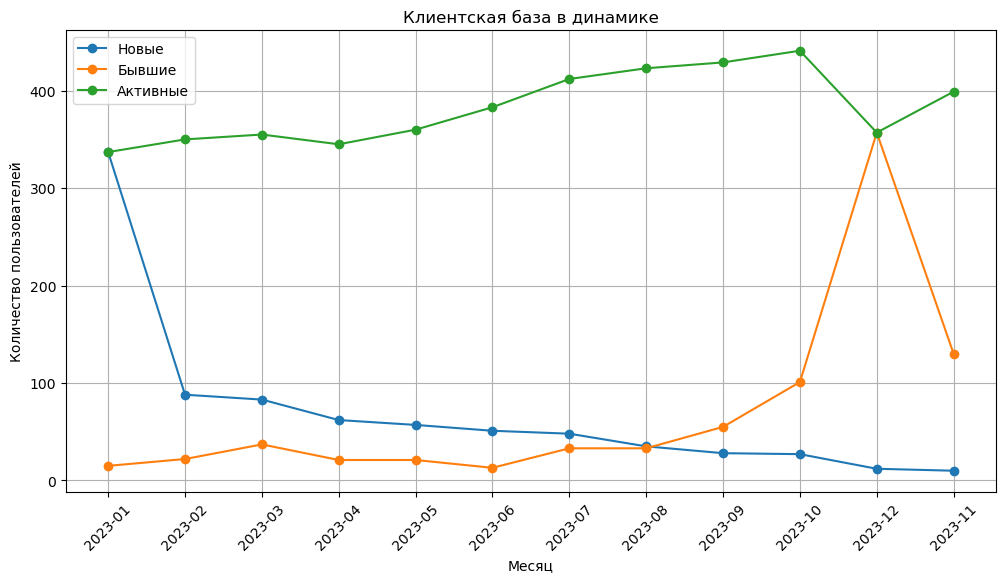

In [16]:
# Динамику всех групп клиентов отобразим на графике
plt.figure(figsize=(12, 6))
plt.plot(df_common['mon'], df_common['first'], label='Новые', marker='o')
plt.plot(df_common['mon'], df_common['last'], label='Бывшие', marker='o')
plt.plot(df_common['mon'], df_common['active'], label='Активные', marker='o')

plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.title('Клиентская база в динамике')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Вывод:**  
* База активных пользователей стабильно росла с января по октябрь 2023 года — с 337 до 441 клиента, несмотря на снижение числа новых регистраций.
* В ноябре–декабре заметен резкий всплеск оттока (357 ушедших в декабре) и падение притока — это может указывать на сезонный спад или проблему удержания.